In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import dlib

In [3]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [4]:
def landmarkes(image):
  # Load Dlib face detector
  detector = dlib.get_frontal_face_detector()


  # Load pretrained 68 facial landmark model
  # ----------------------------------------------------
  predictor = dlib.shape_predictor(
      "/content/drive/MyDrive/Colab Notebooks/videos/shape_predictor_68_face_landmarks.dat"
  )

  # Convert frame to grayscale
  gray = cv.cvtColor(
      image,
      cv.COLOR_BGR2GRAY
  )

  # Detect all faces in current frame
  faces = detector(gray)

  max_area= 0
  landmarks = []
  biggest_face = None
  for face in faces:
    width = face.right() - face.left()
    height = face.bottom() - face.top()
    area = width * height
    if area > max_area:
      max_area = area
      biggest_face = face

  if biggest_face is not None:
      # Predict 68 facial landmarks
      shape = predictor(gray, biggest_face)
      for i in range(68):
        point = shape.part(i)
        # Landmark coordinates
        x = point.x
        y = point.y
        landmarks.append((x, y))
  else:
     return None


  return np.array(landmarks, dtype=np.int32)

In [5]:
def warp_triangle(src_image, dst_image, src_triangle, dst_triangle):
    """
    Warp a triangular region from the source image to the destination image
    using affine transformation.
    """

    # Compute bounding rectangles for source and destination triangles
    src_x, src_y, src_w, src_h = cv.boundingRect(src_triangle)
    dst_x, dst_y, dst_w, dst_h = cv.boundingRect(dst_triangle)

    # Extract regions of interest (ROI)
    src_roi = src_image[src_y:src_y+src_h, src_x:src_x+src_w]
    dst_roi = dst_image[dst_y:dst_y+dst_h, dst_x:dst_x+dst_w]

    # Convert triangle coordinates into local ROI coordinates
    src_triangle_local = src_triangle.copy()
    dst_triangle_local = dst_triangle.copy()

    src_triangle_local -= np.array([src_x, src_y])
    dst_triangle_local -= np.array([dst_x, dst_y])

    # Compute affine transformation matrix
    affine_matrix = cv.getAffineTransform(
        np.float32(src_triangle_local),
        np.float32(dst_triangle_local)
    )

    # Create a mask for the destination triangle
    mask = np.zeros((dst_h, dst_w), np.uint8)
    cv.fillConvexPoly(mask, np.int32(dst_triangle_local), 255)

    # Warp the source triangle into the destination ROI
    warped_triangle = cv.warpAffine(src_roi, affine_matrix, (dst_w, dst_h))
    warped_triangle = cv.bitwise_and(warped_triangle, warped_triangle, mask=mask)

    # Remove the old triangle from destination ROI
    mask_inv = cv.bitwise_not(mask)
    dst_roi = cv.bitwise_and(dst_roi, dst_roi, mask=mask_inv)

    # Blend warped triangle with destination ROI
    result = cv.add(dst_roi, warped_triangle)

    # Copy the blended triangle back into the destination image
    dst_image[
        dst_y:dst_y+dst_h,
        dst_x:dst_x+dst_w
    ] = result

In [6]:
def delaunay_triangulation(image, landmarks):
    """
    Generate Delaunay triangulation and return
    triangle vertex indices based on facial landmarks.
    """

    height, width = image.shape[:2]

    # Initialize OpenCV Delaunay subdivision
    rect = (0, 0, width, height)
    subdiv = cv.Subdiv2D(rect)

    # Insert all facial landmarks
    for point in landmarks:
        subdiv.insert((int(point[0]), int(point[1])))

    # Retrieve generated triangles
    triangle_list = np.array(
        subdiv.getTriangleList(),
        dtype=np.int32
    )

    # Build coordinate-to-index lookup table
    landmark_dict = {}

    for i, point in enumerate(landmarks):
        landmark_dict[(int(point[0]), int(point[1]))] = i

    triangle_indices = []

    # Convert triangle coordinates to landmark indices
    for triangle in triangle_list:

        current_triangle = []

        for i in range(0, len(triangle), 2):

            point = (
                triangle[i],
                triangle[i+1]
            )

            if point in landmark_dict:
                current_triangle.append(
                    landmark_dict[point]
                )

        if len(current_triangle) == 3:
            triangle_indices.append(
                tuple(current_triangle)
            )

    return triangle_indices

In [15]:
def face_swap(source_image, destination_image):
    """
    Perform face swapping between two images using
    Delaunay triangulation and seamless cloning.
    """

    # Detect facial landmarks
    landmarks_1 = landmarkes(source_image)
    landmarks_2 = landmarkes(destination_image)

    if len(landmarks_1) == 0 or len(landmarks_2) == 0:
        return destination_image

    # Build Delaunay triangulation
    triangles = delaunay_triangulation(source_image, landmarks_1)

    if len(triangles) == 0:
        return destination_image

    # Create working copy of destination image
    output = destination_image.copy()

    # Warp every triangle
    for triangle in triangles:

        src_triangle = landmarks_1[list(triangle)]
        dst_triangle = landmarks_2[list(triangle)]

        warp_triangle(
            source_image,
            output,
            src_triangle,
            dst_triangle
        )

    # Build face mask
    hull = cv.convexHull(landmarks_2)

    mask = np.zeros(destination_image.shape[:2], np.uint8)
    cv.fillConvexPoly(mask, np.int32(hull), 255)

    # Compute face center
    x, y, w, h = cv.boundingRect(hull)

    center = (
        x + w // 2,
        y + h // 2
    )

    # Blend swapped face naturally
    result = cv.seamlessClone(
        output,
        destination_image,
        mask,
        center,
        cv.NORMAL_CLONE
    )

    return result

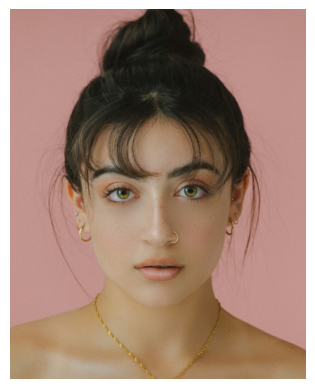

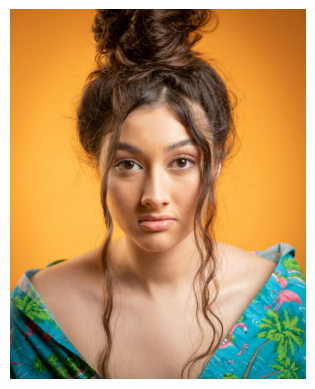

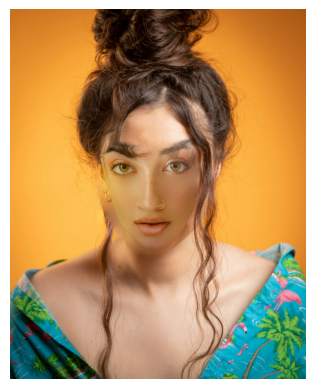

False

In [14]:
# Load source and target images
source_image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/face_2.jpg")
target_image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/face_3.jpg")

if source_image is None:
    raise FileNotFoundError("Source image not found.")

if target_image is None:
    raise FileNotFoundError("Target image not found.")

# Perform face swapping
result = face_swap(source_image, target_image)

# Display images
imshow(source_image)
imshow(target_image)
imshow(result)

# Save output image
cv.imwrite("output/result.jpg", result)